# 📏 Model Evaluation Guide
สรุปวิธีการประเมินโมเดล ML แบบต่างๆ

**เนื้อหา:**
1. Regression Metrics – MAE, MSE, RMSE, R², MAPE
2. Classification Metrics – Accuracy, Precision, Recall, F1, AUC-ROC
3. Confusion Matrix
4. Cross-Validation
5. Clustering Metrics – Silhouette, Davies-Bouldin, Inertia
6. Overfitting / Underfitting Detection
7. Learning Curve
8. สรุปเปรียบเทียบ + เลือก metric อย่างไร

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import (
    load_iris, load_breast_cancer, load_diabetes, make_classification, make_blobs
)
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold,
    cross_validate, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


---
# 1. Regression Metrics

| Metric | สูตร | ช่วง | ดีเมื่อ |
|--------|------|------|--------|
| MAE | mean(|y - ŷ|) | 0 → ∞ | ต่ำ |
| MSE | mean((y - ŷ)²) | 0 → ∞ | ต่ำ |
| RMSE | √MSE | 0 → ∞ | ต่ำ (หน่วยเดียวกับ y) |
| R² | 1 - SS_res/SS_tot | -∞ → 1 | ใกล้ 1 |
| MAPE | mean(|y-ŷ|/y)×100 | 0% → ∞ | ต่ำ |

In [2]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, median_absolute_error,
    explained_variance_score
)

# สร้าง regression dataset
diabetes = load_diabetes()
X_reg, y_reg = diabetes.data, diabetes.target
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

model_reg = LinearRegression().fit(X_tr, y_tr)
y_pred_reg = model_reg.predict(X_te)

mae   = mean_absolute_error(y_te, y_pred_reg)
mse   = mean_squared_error(y_te, y_pred_reg)
rmse  = np.sqrt(mse)
r2    = r2_score(y_te, y_pred_reg)
mape  = mean_absolute_percentage_error(y_te, y_pred_reg) * 100
med_ae = median_absolute_error(y_te, y_pred_reg)
ev    = explained_variance_score(y_te, y_pred_reg)

metrics = pd.DataFrame({
    'Metric': ['MAE','MSE','RMSE','R²','MAPE (%)','Median AE','Explained Variance'],
    'Value':  [mae, mse, rmse, r2, mape, med_ae, ev],
    'Interpretation': [
        'ค่าเฉลี่ยของ error (หน่วยเดียวกับ y) – robust ต่อ outlier',
        'ลงโทษ outlier หนัก (ยกกำลัง 2) – ไวต่อ outlier',
        'RMSE – หน่วยเดียวกับ y ดีกว่า MSE สำหรับ interpret',
        'สัดส่วน variance ที่ model อธิบายได้ (1.0 = perfect)',
        'Error เป็น % ของค่าจริง – ใช้เมื่อ scale ต่างกัน',
        'Median of error – robust มาก ไม่ไวต่อ outlier',
        'คล้าย R² แต่ไม่บังคับ intercept=0',
    ]
})
print(metrics.to_string(index=False))

# PARAMETERS mean_squared_error:
# squared=True  → MSE (default)
# squared=False → RMSE  (deprecated ใน sklearn ใหม่ ใช้ root_mean_squared_error แทน)

            Metric       Value                                            Interpretation
               MAE   42.794095 ค่าเฉลี่ยของ error (หน่วยเดียวกับ y) – robust ต่อ outlier
               MSE 2900.193628            ลงโทษ outlier หนัก (ยกกำลัง 2) – ไวต่อ outlier
              RMSE   53.853446        RMSE – หน่วยเดียวกับ y ดีกว่า MSE สำหรับ interpret
                R²    0.452603      สัดส่วน variance ที่ model อธิบายได้ (1.0 = perfect)
          MAPE (%)   37.499826          Error เป็น % ของค่าจริง – ใช้เมื่อ scale ต่างกัน
         Median AE   37.988200             Median of error – robust มาก ไม่ไวต่อ outlier
Explained Variance    0.455493                         คล้าย R² แต่ไม่บังคับ intercept=0


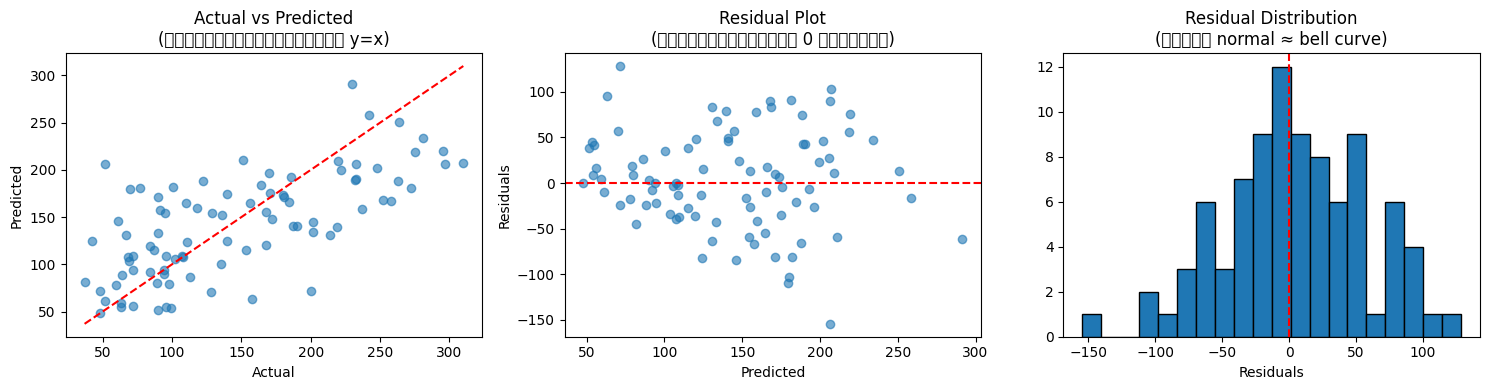

In [3]:
# Residual Plot – วิเคราะห์ error ของ regression
residuals = y_te - y_pred_reg

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual vs Predicted
axes[0].scatter(y_te, y_pred_reg, alpha=0.6)
axes[0].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted\n(ดีคือจุดอยู่บนเส้น y=x)')

# Residual vs Predicted
axes[1].scatter(y_pred_reg, residuals, alpha=0.6)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot\n(ดีคือกระจายรอบ 0 แบบสุ่ม)')

# Residual Distribution
axes[2].hist(residuals, bins=20, edgecolor='black')
axes[2].axvline(0, color='r', linestyle='--')
axes[2].set_xlabel('Residuals')
axes[2].set_title('Residual Distribution\n(ดีคือ normal ≈ bell curve)')

plt.tight_layout()
plt.show()

---
# 2. Classification Metrics

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, balanced_accuracy_score,
    cohen_kappa_score, matthews_corrcoef
)

# Binary classification dataset
cancer = load_breast_cancer()
X_clf, y_clf = cancer.data, cancer.target
X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.2,
                                            random_state=42, stratify=y_clf)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s  = sc.transform(X_te)

clf = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)
y_pred = clf.predict(X_te_s)
y_prob = clf.predict_proba(X_te_s)[:, 1]

print('=== Classification Metrics ===')
print(f'Accuracy:           {accuracy_score(y_te, y_pred):.4f}')
print(f'Balanced Accuracy:  {balanced_accuracy_score(y_te, y_pred):.4f}')
print(f'Precision (macro):  {precision_score(y_te, y_pred, average="macro"):.4f}')
print(f'Recall (macro):     {recall_score(y_te, y_pred, average="macro"):.4f}')
print(f'F1 (macro):         {f1_score(y_te, y_pred, average="macro"):.4f}')
print(f'Cohen Kappa:        {cohen_kappa_score(y_te, y_pred):.4f}')
print(f'Matthews Corr:      {matthews_corrcoef(y_te, y_pred):.4f}')

# average parameter:
# 'binary'   → binary classification (default)
# 'micro'    → TP/FP/FN รวมทุก class
# 'macro'    → เฉลี่ยทุก class เท่ากัน (ไม่สนสัดส่วน)
# 'weighted' → เฉลี่ยถ่วงน้ำหนักตาม class support
# None       → return แต่ละ class แยก

=== Classification Metrics ===
Accuracy:           0.9825
Balanced Accuracy:  0.9812
Precision (macro):  0.9812
Recall (macro):     0.9812
F1 (macro):         0.9812
Cohen Kappa:        0.9623
Matthews Corr:      0.9623


In [5]:
# classification_report – สรุปครบทุก metric
print('=== Classification Report ===')
print(classification_report(y_te, y_pred, target_names=cancer.target_names))

# PARAMETERS classification_report:
# target_names=[...]  → ชื่อ class
# digits=3            → จำนวน decimal
# output_dict=True    → return dict (แทน string)

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [6]:
# ======================================================
# เข้าใจ Precision vs Recall vs F1
# ======================================================

# TP = True Positive,  FP = False Positive
# TN = True Negative,  FN = False Negative
#
# Precision = TP / (TP+FP)  → บอกว่าที่ทำนายว่า Positive จริงกี่%
#   → ใช้เมื่อ: ต้องการให้ FP ต่ำ (spam filter, fraud alert)
#
# Recall = TP / (TP+FN)     → บอกว่าจาก Positive จริงๆ ทำนายถูกกี่%
#   → ใช้เมื่อ: ต้องการให้ FN ต่ำ (cancer detection, fraud detection)
#
# F1 = 2 * (P*R)/(P+R)      → harmonic mean ของ P และ R
#   → ใช้เมื่อ: ต้องการ balance ระหว่าง P และ R
#
# F-beta = (1+β²) * P*R / (β²*P + R)
#   β > 1 → เน้น Recall,  β < 1 → เน้น Precision

from sklearn.metrics import fbeta_score, precision_recall_curve

f2 = fbeta_score(y_te, y_pred, beta=2)  # เน้น Recall มากกว่า
f05 = fbeta_score(y_te, y_pred, beta=0.5)  # เน้น Precision มากกว่า
print(f'F2  (เน้น Recall):    {f2:.4f}')
print(f'F0.5 (เน้น Precision): {f05:.4f}')

F2  (เน้น Recall):    0.9861
F0.5 (เน้น Precision): 0.9861


---
# 3. Confusion Matrix

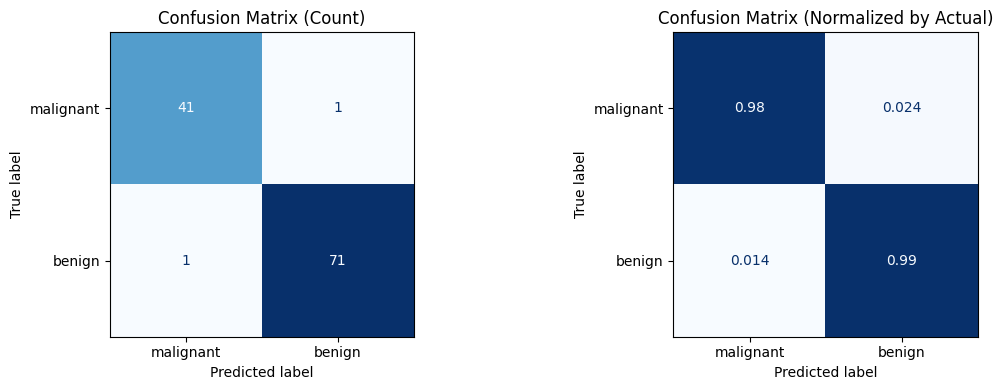

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_te, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw count
disp1 = ConfusionMatrixDisplay(cm, display_labels=cancer.target_names)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Count)')

# Normalized (row = actual)
cm_norm = confusion_matrix(y_te, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=cancer.target_names)
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized by Actual)')

plt.tight_layout()
plt.show()

# PARAMETERS confusion_matrix:
# normalize='true'     → normalize by actual (rows)
# normalize='pred'     → normalize by predicted (cols)
# normalize='all'      → normalize by total
# labels=[...]         → กำหนด order ของ class

---
# 4. ROC Curve & AUC / Precision-Recall Curve

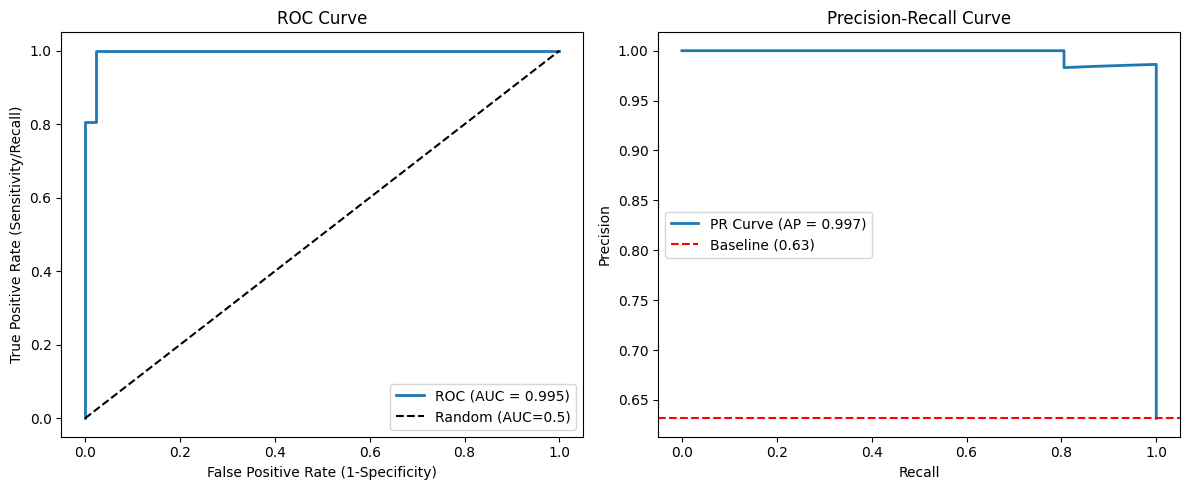

AUC-ROC interpretation:
  1.0 = perfect | 0.9+ = excellent | 0.8+ = good | 0.7+ = fair | 0.5 = random

ใช้ PR Curve แทน ROC เมื่อ class imbalanced มาก


In [8]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- ROC Curve ----
fpr, tpr, roc_thresh = roc_curve(y_te, y_prob)
auc_score = roc_auc_score(y_te, y_prob)

axes[0].plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc_score:.3f})')
axes[0].plot([0,1],[0,1], 'k--', label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate (1-Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity/Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend()

# ---- Precision-Recall Curve ----
prec, rec, pr_thresh = precision_recall_curve(y_te, y_prob)
ap = average_precision_score(y_te, y_prob)

axes[1].plot(rec, prec, lw=2, label=f'PR Curve (AP = {ap:.3f})')
baseline = y_te.sum() / len(y_te)
axes[1].axhline(baseline, color='r', linestyle='--', label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print('AUC-ROC interpretation:')
print('  1.0 = perfect | 0.9+ = excellent | 0.8+ = good | 0.7+ = fair | 0.5 = random')
print('\nใช้ PR Curve แทน ROC เมื่อ class imbalanced มาก')

# PARAMETERS roc_auc_score:
# average='macro'      → multiclass
# multi_class='ovr'   → One-vs-Rest
# multi_class='ovo'   → One-vs-One

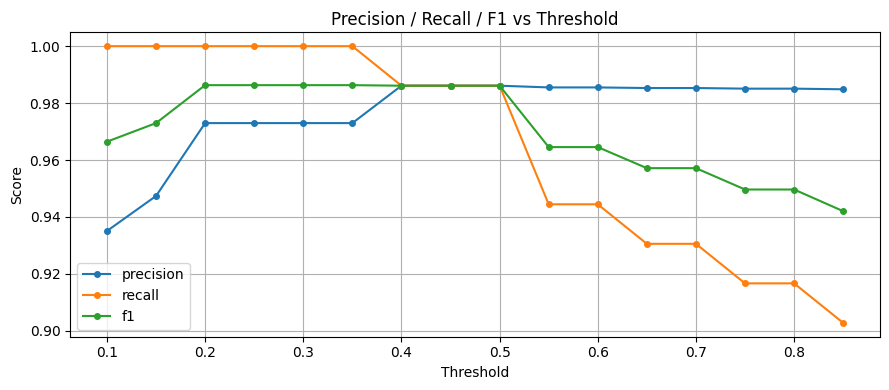

Best F1 threshold: 0.20 → F1=0.986


In [9]:
# ======================================================
# Threshold Tuning – เลือก threshold เองได้
# ======================================================

thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': precision_score(y_te, y_pred_t, zero_division=0),
        'recall':    recall_score(y_te, y_pred_t, zero_division=0),
        'f1':        f1_score(y_te, y_pred_t, zero_division=0),
    })

df_thresh = pd.DataFrame(results)

plt.figure(figsize=(9, 4))
for col in ['precision', 'recall', 'f1']:
    plt.plot(df_thresh['threshold'], df_thresh[col], label=col, marker='o', markersize=4)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_f1_idx = df_thresh['f1'].idxmax()
print(f"Best F1 threshold: {df_thresh.loc[best_f1_idx, 'threshold']:.2f} "
      f"→ F1={df_thresh.loc[best_f1_idx, 'f1']:.3f}")

---
# 5. Cross-Validation

In [10]:
# ======================================================
# 5.1 cross_val_score – ง่าย รวดเร็ว
# ======================================================

X, y = load_iris(return_X_y=True)
model_cv = LogisticRegression(max_iter=200)

# KFold
scores_kf = cross_val_score(model_cv, X, y,
                             cv=5,           # จำนวน folds
                             scoring='accuracy')
print(f'KFold CV (k=5):')
print(f'  Scores: {scores_kf.round(3)}')
print(f'  Mean ± Std: {scores_kf.mean():.3f} ± {scores_kf.std():.3f}')

# Stratified KFold (รักษาสัดส่วน class)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = cross_val_score(model_cv, X, y, cv=skf, scoring='f1_macro')
print(f'\nStratifiedKFold (k=5) F1 macro:')
print(f'  Mean ± Std: {scores_skf.mean():.3f} ± {scores_skf.std():.3f}')

# Scoring options:
# 'accuracy', 'f1', 'f1_macro', 'f1_weighted'
# 'precision', 'recall', 'roc_auc'
# 'r2', 'neg_mean_absolute_error', 'neg_rmse'
# 'neg_mean_squared_error'  (negative เพราะ sklearn maximize)

KFold CV (k=5):
  Scores: [0.967 1.    0.933 0.967 1.   ]
  Mean ± Std: 0.973 ± 0.025

StratifiedKFold (k=5) F1 macro:
  Mean ± Std: 0.967 ± 0.030


In [11]:
# ======================================================
# 5.2 cross_validate – ได้หลาย metrics พร้อมกัน
# ======================================================

cv_results = cross_validate(
    model_cv, X, y,
    cv=5,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    return_train_score=True,   # ได้ train score ด้วย (detect overfitting)
    return_estimator=False,    # เก็บ trained model แต่ละ fold ไว้
)

cv_df = pd.DataFrame(cv_results)
print(cv_df[['train_accuracy','test_accuracy','test_f1_macro','test_precision_macro']].round(3))
print(f'\nTest Accuracy: {cv_df["test_accuracy"].mean():.3f} ± {cv_df["test_accuracy"].std():.3f}')
print(f'Train Accuracy: {cv_df["train_accuracy"].mean():.3f} ± {cv_df["train_accuracy"].std():.3f}')

# PARAMETERS cross_validate:
# return_train_score=True  → แสดง train score (เปรียบ overfit)
# return_estimator=True    → เก็บ fitted model แต่ละ fold
# n_jobs=-1                → ใช้ทุก CPU

   train_accuracy  test_accuracy  test_f1_macro  test_precision_macro
0           0.967          0.967          0.967                 0.970
1           0.967          1.000          1.000                 1.000
2           0.983          0.933          0.933                 0.944
3           0.983          0.967          0.967                 0.970
4           0.975          1.000          1.000                 1.000

Test Accuracy: 0.973 ± 0.028
Train Accuracy: 0.975 ± 0.008


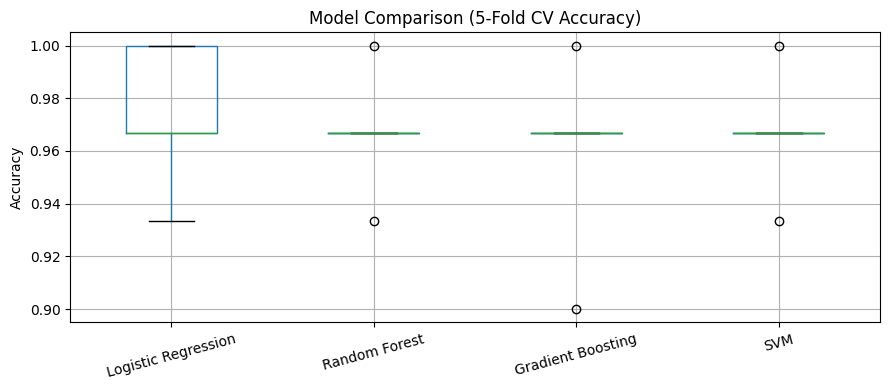

Mean Accuracy:
Logistic Regression    0.9733
Random Forest          0.9667
SVM                    0.9667
Gradient Boosting      0.9600
dtype: float64


In [12]:
# ======================================================
# 5.3 เปรียบเทียบหลาย models ด้วย CV
# ======================================================

models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True),
}

compare = {}
for name, model in models.items():
    s = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    compare[name] = s

compare_df = pd.DataFrame(compare)

fig, ax = plt.subplots(figsize=(9, 4))
compare_df.boxplot(ax=ax)
ax.set_title('Model Comparison (5-Fold CV Accuracy)')
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print('Mean Accuracy:')
print(compare_df.mean().sort_values(ascending=False).round(4))

---
# 6. Clustering Metrics

In [13]:
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score
)

# สร้าง clustering data
X_cl, y_true_cl = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# ---- Internal Metrics (ไม่ต้องการ ground truth) ----
results = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cl)
    results.append({
        'k': k,
        'inertia':    km.inertia_,
        'silhouette': silhouette_score(X_cl, labels),
        'davies_bouldin': davies_bouldin_score(X_cl, labels),
        'calinski_harabasz': calinski_harabasz_score(X_cl, labels),
    })

df_cluster = pd.DataFrame(results)
print(df_cluster.round(3).to_string(index=False))
print('\nตีความ:')
print('  Inertia:             ต่ำ = ดี (Elbow Method)')
print('  Silhouette:          สูง = ดี (-1 to 1, เป้าหมาย > 0.5)')
print('  Davies-Bouldin:      ต่ำ = ดี (≥ 0)')
print('  Calinski-Harabasz:   สูง = ดี')

 k  inertia  silhouette  davies_bouldin  calinski_harabasz
 2 9211.211       0.603           0.504            341.928
 3 1919.365       0.778           0.334           1381.885
 4  362.472       0.834           0.232           5285.609
 5  329.268       0.698           0.625           4361.430
 6  294.606       0.588           0.840           3889.117
 7  261.564       0.449           0.995           3649.099

ตีความ:
  Inertia:             ต่ำ = ดี (Elbow Method)
  Silhouette:          สูง = ดี (-1 to 1, เป้าหมาย > 0.5)
  Davies-Bouldin:      ต่ำ = ดี (≥ 0)
  Calinski-Harabasz:   สูง = ดี


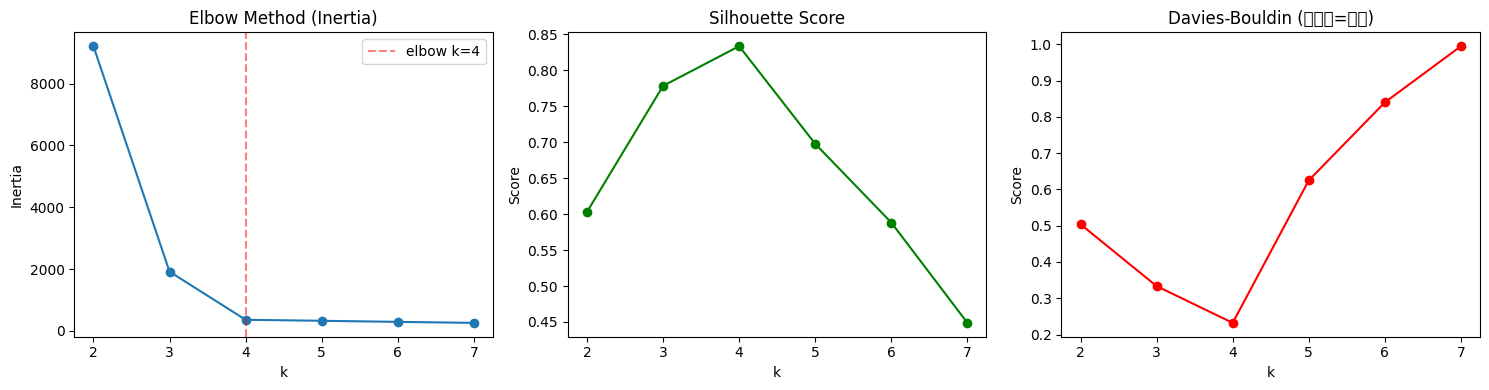

External Metrics (เทียบกับ true labels):
  Adjusted Rand Index: 1.000  (1=perfect)
  NMI Score:           1.000  (1=perfect)


In [14]:
# Elbow + Silhouette plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_cluster['k'], df_cluster['inertia'], marker='o')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].axvline(4, color='r', linestyle='--', alpha=0.5, label='elbow k=4')
axes[0].legend()

axes[1].plot(df_cluster['k'], df_cluster['silhouette'], marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')

axes[2].plot(df_cluster['k'], df_cluster['davies_bouldin'], marker='o', color='red')
axes[2].set_title('Davies-Bouldin (ต่ำ=ดี)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Score')

plt.tight_layout()
plt.show()

# External Metrics (ต้องการ ground truth)
km4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_cl)
pred_labels = km4.labels_
print('External Metrics (เทียบกับ true labels):')
print(f'  Adjusted Rand Index: {adjusted_rand_score(y_true_cl, pred_labels):.3f}  (1=perfect)')
print(f'  NMI Score:           {normalized_mutual_info_score(y_true_cl, pred_labels):.3f}  (1=perfect)')

---
# 7. Learning Curve & Validation Curve – ตรวจ Overfitting

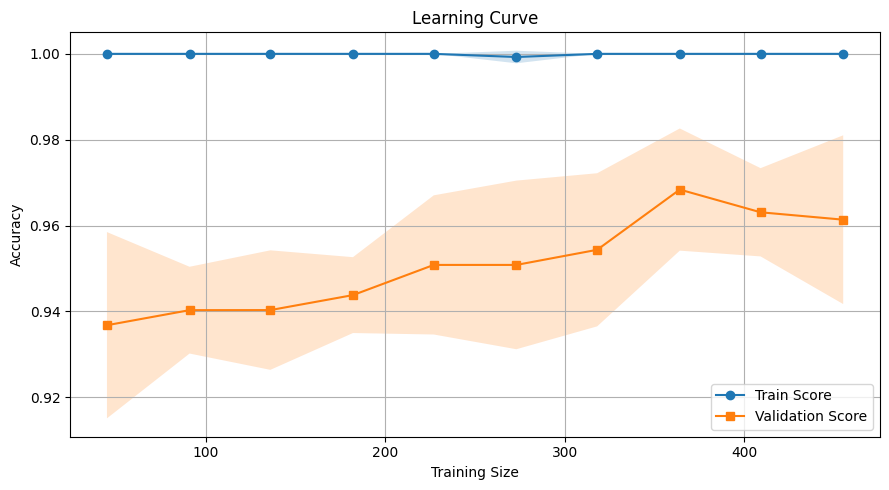

การอ่าน Learning Curve:
  ช่อง train-val กว้าง  → Overfit (ต้องการข้อมูลเพิ่ม หรือ regularize)
  ทั้งคู่ต่ำ + converge  → Underfit (model ซับซ้อนขึ้น)
  ทั้งคู่สูง + converge  → ดี


In [15]:
# ======================================================
# 7.1 Learning Curve – ผล vs จำนวน training data
# ======================================================

X, y = load_breast_cancer(return_X_y=True)
model_lc = RandomForestClassifier(n_estimators=50, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10%-100% ของ train data
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    shuffle=True,
    random_state=42,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Train Score')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, 's-', label='Validation Score')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('การอ่าน Learning Curve:')
print('  ช่อง train-val กว้าง  → Overfit (ต้องการข้อมูลเพิ่ม หรือ regularize)')
print('  ทั้งคู่ต่ำ + converge  → Underfit (model ซับซ้อนขึ้น)')
print('  ทั้งคู่สูง + converge  → ดี')

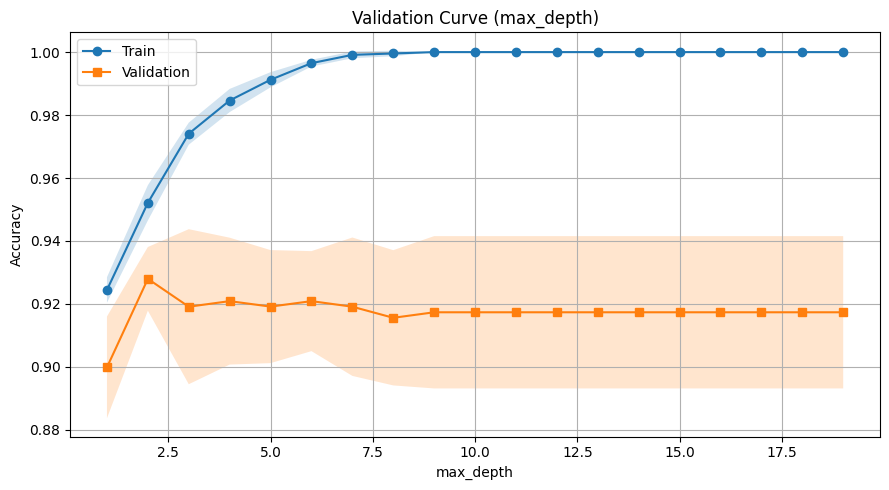

Best max_depth: 2


In [16]:
# ======================================================
# 7.2 Validation Curve – ผล vs hyperparameter
# ======================================================

from sklearn.tree import DecisionTreeClassifier

param_range = np.arange(1, 20)
train_sc, val_sc = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X, y,
    param_name='max_depth',   # hyperparameter ที่ต้องการทดสอบ
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

plt.figure(figsize=(9, 5))
plt.plot(param_range, train_sc.mean(axis=1), 'o-', label='Train')
plt.fill_between(param_range,
                 train_sc.mean(axis=1)-train_sc.std(axis=1),
                 train_sc.mean(axis=1)+train_sc.std(axis=1), alpha=0.2)
plt.plot(param_range, val_sc.mean(axis=1), 's-', label='Validation')
plt.fill_between(param_range,
                 val_sc.mean(axis=1)-val_sc.std(axis=1),
                 val_sc.mean(axis=1)+val_sc.std(axis=1), alpha=0.2)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Validation Curve (max_depth)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_depth = param_range[val_sc.mean(axis=1).argmax()]
print(f'Best max_depth: {best_depth}')

---
# 8. Multiclass ROC – OvR

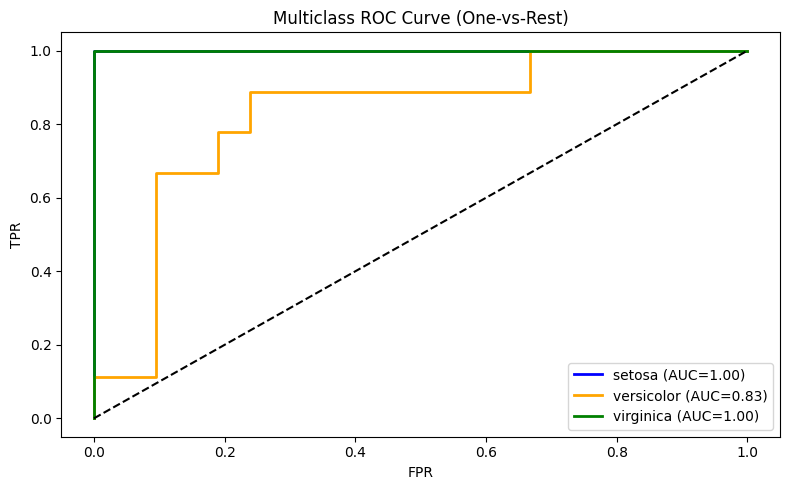

In [17]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

X_iris, y_iris = load_iris(return_X_y=True)
classes = [0, 1, 2]
y_bin = label_binarize(y_iris, classes=classes)

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_iris, y_bin, test_size=0.2, random_state=42
)

from sklearn.multiclass import OneVsRestClassifier
clf_m = OneVsRestClassifier(LogisticRegression(max_iter=200))
clf_m.fit(X_tr_m, y_tr_m)
y_score = clf_m.predict_proba(X_te_m)

plt.figure(figsize=(8, 5))
colors = ['blue','orange','green']
for i, (cls, col) in enumerate(zip(load_iris().target_names, colors)):
    fpr, tpr, _ = roc_curve(y_te_m[:, i], y_score[:, i])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={auc_val:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend()
plt.tight_layout()
plt.show()

---
# สรุปตาราง: เลือก Metric อย่างไร?

## Regression
| ปัญหา | Metric แนะนำ |
|-------|-------------|
| ทั่วไป | RMSE + R² |
| มี outlier เยอะ | MAE หรือ Median AE |
| ต้องการ % error | MAPE |
| เปรียบ scale ต่างกัน | MAPE หรือ R² |

## Classification
| ปัญหา | Metric แนะนำ |
|-------|-------------|
| Class balanced | Accuracy + F1 macro |
| Class imbalanced | F1 weighted / PR-AUC |
| ต้องการลด FP (spam) | Precision |
| ต้องการลด FN (cancer) | Recall |
| Ranking / probability | AUC-ROC |
| Multiclass | F1 macro / weighted |

## Clustering
| มี ground truth | ไม่มี ground truth |
|-----------------|-------------------|
| Adjusted Rand Index | Silhouette Score |
| NMI Score | Davies-Bouldin |
| | Calinski-Harabasz |

## Cross-Validation Strategy
| ข้อมูล | วิธี CV |
|--------|--------|
| ทั่วไป | KFold(k=5 หรือ 10) |
| Class imbalanced | StratifiedKFold |
| Time series | TimeSeriesSplit |
| ข้อมูลน้อยมาก | Leave-One-Out (LOO) |